# Streaming Data Load

Load raw per-dump `.npz` files from `data/lab03/streaming/sun/` and assemble
them into the array format used by the analysis notebooks (02a onwards).

Each streaming file contains a single SNAP accumulator dump with keys:
- `corr01` — complex cross-correlation spectrum (1024 channels)
- `time` — Unix timestamp (seconds, scalar)
- `acc_cnt` — accumulation count
- `target_name`, `alt_deg`, `az_deg`, `ra_deg`, `dec_deg` — pointing
- `seq` — sequence number within the observation

The data collection script (`stream_calibration.py`) also records an
**auto-correlation calibration scan** at the start of the observation:
per-antenna power spectra (`auto0`, `auto1`) saved to
`data/lab03/streaming/calibration/autocorr_*.npz`. These provide the
system temperature product $P_0 \cdot P_1$ needed to estimate the
per-channel noise $\sigma_V$ on the cross-correlation via the radiometer
equation.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    F_S_HZ, N_FFT, F_RF0_HZ, PLOT_BAND_GHZ,
    BAD_CHANNELS,
    NOMINAL_B_EW_M,
    lst_deg, hour_angle_deg,
    adaptive_real_dc_correction,
    NEUTRAL_COLOR,
    LW_FINE, LW_LIGHT, LW_STANDARD,
    TEXTWIDTH_IN, TICK_SIZE,
)

COMPONENT_COLORS = [f"C{i}" for i in range(10)]

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


## 1. Discover and load raw dumps

Each file is one SNAP accumulation (~1.25 s cadence). We sort by filename
(which embeds a timestamp and sequence number) and stack into arrays.

In [2]:
DATA_DIR = Path("../../../data/lab03/streaming/sun")
dump_paths = sorted(DATA_DIR.glob("sun_dump_*.npz"))
N_dumps = len(dump_paths)
print(f"Found {N_dumps} dump files in {DATA_DIR}")

# Peek at the first file for array dimensions
with np.load(dump_paths[0], allow_pickle=True) as first:
    N_CH = first["corr01"].shape[0]
    print(f"Channels per dump: {N_CH}")

# Pre-allocate
corr_raw    = np.empty((N_dumps, N_CH), dtype=complex)
unix_arr    = np.empty(N_dumps, dtype=float)
acc_cnt_arr = np.empty(N_dumps, dtype=int)
alt_deg_arr = np.empty(N_dumps, dtype=float)
az_deg_arr  = np.empty(N_dumps, dtype=float)
ra_deg_arr  = np.empty(N_dumps, dtype=float)
dec_deg_arr = np.empty(N_dumps, dtype=float)
seq_arr     = np.empty(N_dumps, dtype=int)

for i, path in enumerate(dump_paths):
    with np.load(path, allow_pickle=True) as npz:
        corr_raw[i]    = npz["corr01"]
        unix_arr[i]    = float(npz["time"])
        acc_cnt_arr[i] = int(npz["acc_cnt"])
        alt_deg_arr[i] = float(npz["alt_deg"])
        az_deg_arr[i]  = float(npz["az_deg"])
        ra_deg_arr[i]  = float(npz["ra_deg"])
        dec_deg_arr[i] = float(npz["dec_deg"])
        seq_arr[i]     = int(npz["seq"])
    if (i + 1) % 200 == 0:
        print(f"  loaded {i + 1}/{N_dumps}")

print(f"Loaded {N_dumps} dumps, shape = {corr_raw.shape}")

Found 1885 dump files in ../../../data/lab03/streaming/sun
Channels per dump: 1024
  loaded 200/1885
  loaded 400/1885
  loaded 600/1885
  loaded 800/1885
  loaded 1000/1885
  loaded 1200/1885
  loaded 1400/1885
  loaded 1600/1885
  loaded 1800/1885
Loaded 1885 dumps, shape = (1885, 1024)


## 1b. Load auto-correlation calibration

The script collects per-antenna power spectra (`auto0`, `auto1`) before
switching to cross-correlation mode. The time-averaged auto-correlations
give a noise estimate via the radiometer equation:

$$\sigma_V(\nu) = \frac{\sqrt{\langle P_0(\nu)\rangle \cdot \langle P_1(\nu)\rangle}}{n_{\mathrm{acc}}}$$

where $n_{\mathrm{acc}}$ is the accumulation count per dump.

In [3]:
# ── Load auto-correlation calibration ───────────────────────────────
CAL_DIR = Path("../../../data/lab03/streaming/calibration")
cal_path = sorted(CAL_DIR.glob("autocorr_*.npz"))[-1]

with np.load(cal_path, allow_pickle=True) as cal:
    auto0 = np.asarray(cal["auto0"], dtype=float)  # (n_cal, N_CH)
    auto1 = np.asarray(cal["auto1"], dtype=float)
    cal_times = np.asarray(cal["times"], dtype=float)

# Time-averaged per-channel auto-correlation power
auto0_mean = np.nanmean(auto0, axis=0)
auto1_mean = np.nanmean(auto1, axis=0)

# Radiometer noise estimate per channel per dump
median_acc = int(np.median(acc_cnt_arr))
corr_std = np.sqrt(auto0_mean * auto1_mean) / median_acc

print(f"Loaded calibration: {cal_path.name}")
print(f"  auto0: {auto0.shape}, auto1: {auto1.shape}")
print(f"  Median acc_cnt: {median_acc}")

Loaded calibration: autocorr_20260415_182712.npz
  auto0: (20, 1024), auto1: (20, 1024)
  Median acc_cnt: 968


## 2. Derive auxiliary quantities

Compute the frequency axis, hour angle, cadence, and per-channel noise
estimate to match the variables the downstream notebooks expect.

In [4]:
# ── Frequency axis ──────────────────────────────────────────────────
DF_HZ = F_S_HZ / N_FFT
F_SKY_HZ = F_RF0_HZ + np.arange(N_CH) * DF_HZ
F_SKY_GHZ = F_SKY_HZ / 1e9

# ── Analysis band mask ──────────────────────────────────────────────
band_mask = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
for bc in BAD_CHANNELS:
    band_mask[bc] = False

# ── Hour angle ──────────────────────────────────────────────────────
lst_arr = lst_deg(unix_arr)
ha_deg_arr = hour_angle_deg(lst_arr, ra_deg_arr)

# ── Cadence ────────────────────────────────────────────────────────
dt = np.diff(unix_arr)
median_cadence = float(np.median(dt))

# ── Band-averaged visibility ───────────────────────────────────────
corr_band = corr_raw[:, band_mask]

print(f"Frequency axis: {F_SKY_GHZ[0]:.3f} – {F_SKY_GHZ[-1]:.3f} GHz")
print(f"Analysis band: {PLOT_BAND_GHZ[0]:.3f} – {PLOT_BAND_GHZ[1]:.3f} GHz  "
      f"({band_mask.sum()} good channels)")
print(f"HA range: {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")
print(f"Median cadence: {median_cadence:.3f} s")
print(f"Time span: {(unix_arr[-1] - unix_arr[0]) / 3600:.2f} hours")
print(f"Sun dec range: {dec_deg_arr.min():.3f} to {dec_deg_arr.max():.3f} deg")

Frequency axis: 10.290 – 10.540 GHz
Analysis band: 10.415 – 10.485 GHz  (285 good channels)
HA range: 80.0 to 89.8 deg
Median cadence: 1.269 s
Time span: 0.65 hours
Sun dec range: 9.935 to 9.945 deg


## 3. Raw visibility vs hour angle (representative channel)

Four-panel plot of Re, Im, amplitude, and phase at a single mid-band
channel, matching the layout of notebook 02a.

/tmp/ipykernel_213819/1751611240.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


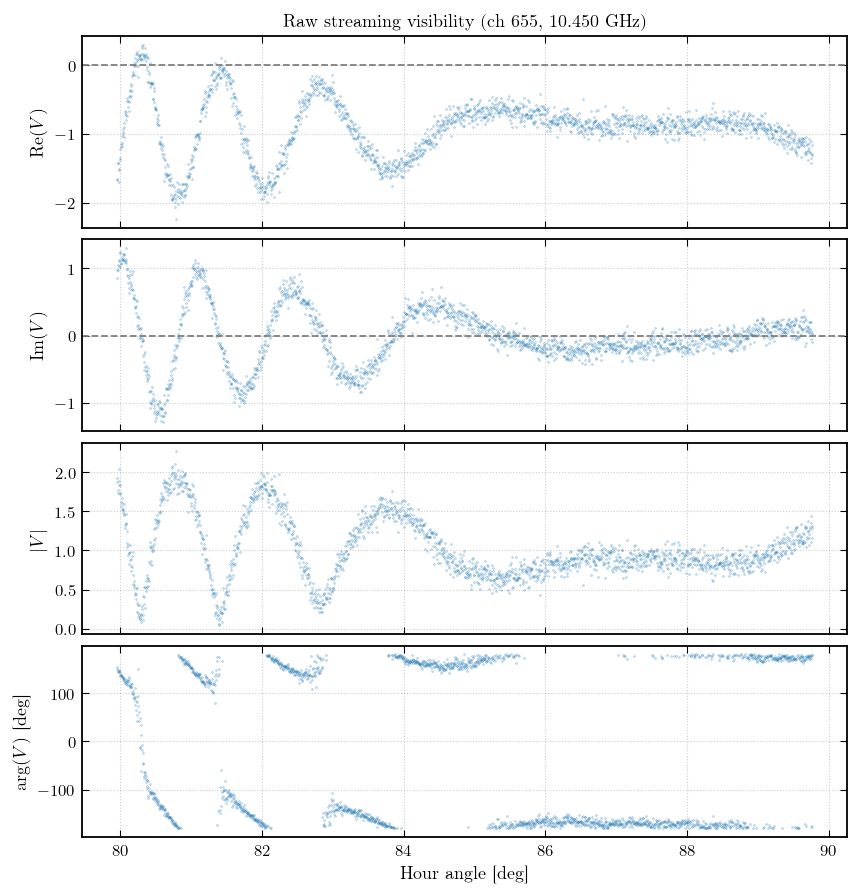

In [5]:
band_indices = np.where(band_mask)[0]
k_mid = band_indices[len(band_indices) // 2]
f_mid_ghz = F_SKY_GHZ[k_mid]
vis_ch = corr_raw[:, k_mid]

fig, axes = plt.subplots(4, 1, figsize=(TEXTWIDTH_IN, 8.0), sharex=True,
                         gridspec_kw={"hspace": 0.06})

titles = [r"Re$(V)$", r"Im$(V)$", r"$|V|$", r"$\arg(V)$ [deg]"]
data   = [vis_ch.real, vis_ch.imag, np.abs(vis_ch), np.angle(vis_ch, deg=True)]

for ax, title, y in zip(axes, titles, data):
    ax.scatter(ha_deg_arr, y, s=0.15, color="C0",
               alpha=0.4, rasterized=True)
    ax.set_ylabel(title, fontsize=TICK_SIZE)
    ax.tick_params(labelsize=TICK_SIZE - 1)
    if "Re" in title or "Im" in title:
        ax.axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")

axes[0].set_title(f"Raw streaming visibility (ch {k_mid}, {f_mid_ghz:.3f} GHz)",
                  fontsize=TICK_SIZE)
axes[-1].set_xlabel("Hour angle [deg]")
fig.tight_layout()
plt.show()

## 4. Time-averaged amplitude spectrum

Shows the IF bandpass shape, bad channels, and the usable analysis band.

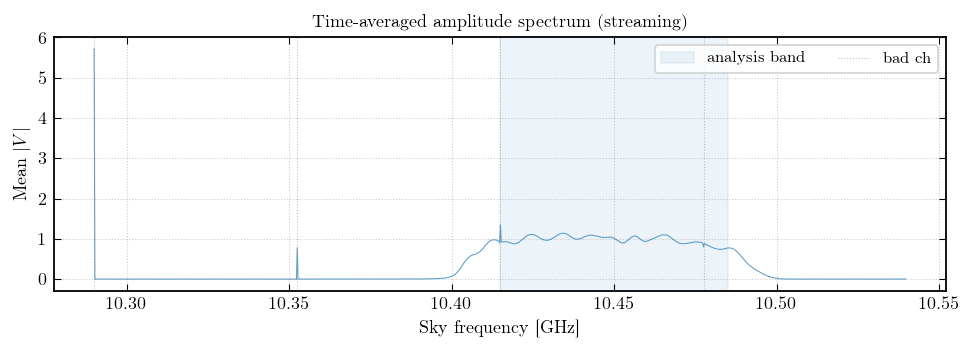

In [6]:
mean_amp = np.nanmean(np.abs(corr_raw), axis=0)

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.8))
ax.plot(F_SKY_GHZ, mean_amp, lw=LW_FINE, color="C0", alpha=0.7)
ax.axvspan(PLOT_BAND_GHZ[0], PLOT_BAND_GHZ[1], alpha=0.08, color="C0",
           label="analysis band")
for bc in BAD_CHANNELS:
    ax.axvline(F_SKY_GHZ[bc], color=NEUTRAL_COLOR, lw=LW_FINE, ls=":", alpha=0.5,
               label="bad ch" if bc == BAD_CHANNELS[0] else None)
ax.set_xlabel("Sky frequency [GHz]")
ax.set_ylabel("Mean $|V|$")
ax.set_title("Time-averaged amplitude spectrum (streaming)", fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE - 1, ncol=2)
fig.tight_layout()
plt.show()

## 4b. Adaptive DC correction

The raw real part has a slowly-varying DC pedestal from system-temperature
drift, ground spillover, and back-end offsets. We remove it with the same
adaptive rolling-median used in notebook 02b: the window width scales with
the local fringe period $P_f(h) \propto 1/|\cos h|$, keeping a constant
number of fringe cycles inside the window regardless of hour angle.

The streaming data is a single continuous run (no chip boundaries), so we
pass it as a one-element list to `adaptive_real_dc_correction`.

In [7]:
# ── Adaptive DC correction ──────────────────────────────────────────
ha_rad_arr = np.deg2rad(ha_deg_arr)
dec_rad_mean = np.deg2rad(np.nanmean(dec_deg_arr))
band_center_hz = float(np.mean(F_SKY_HZ[band_mask]))
bad_ch_arr = np.array(BAD_CHANNELS, dtype=int)

N_PERIODS       = 3.0
MIN_WINDOW_CAPS = 7
MAX_WINDOW_CAPS = 201

dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw],
    unix_chips=[unix_arr],
    ha_rad_chips=[ha_rad_arr],
    bad_channels=bad_ch_arr,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=N_PERIODS,
    min_window_caps=MIN_WINDOW_CAPS,
    max_window_caps=MAX_WINDOW_CAPS,
)
corr_dc = dc_result.corr_dc
real_offset = dc_result.real_offset_chips[0]
window_caps = dc_result.window_caps

wc = dc_result.window_caps_chips[0]
print(f"DC correction: {N_PERIODS} periods/window, "
      f"clamp [{MIN_WINDOW_CAPS}, {MAX_WINDOW_CAPS}] caps")
print(f"  Window range: {wc.min()}–{wc.max()} caps "
      f"({wc.min() * median_cadence:.0f}–{wc.max() * median_cadence:.0f} s)")
print(f"  Output shape: {corr_dc.shape}")

DC correction: 3.0 periods/window, clamp [7, 201] caps
  Window range: 201–201 caps (255–255 s)
  Output shape: (1885, 1024)


/tmp/ipykernel_213819/316022253.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


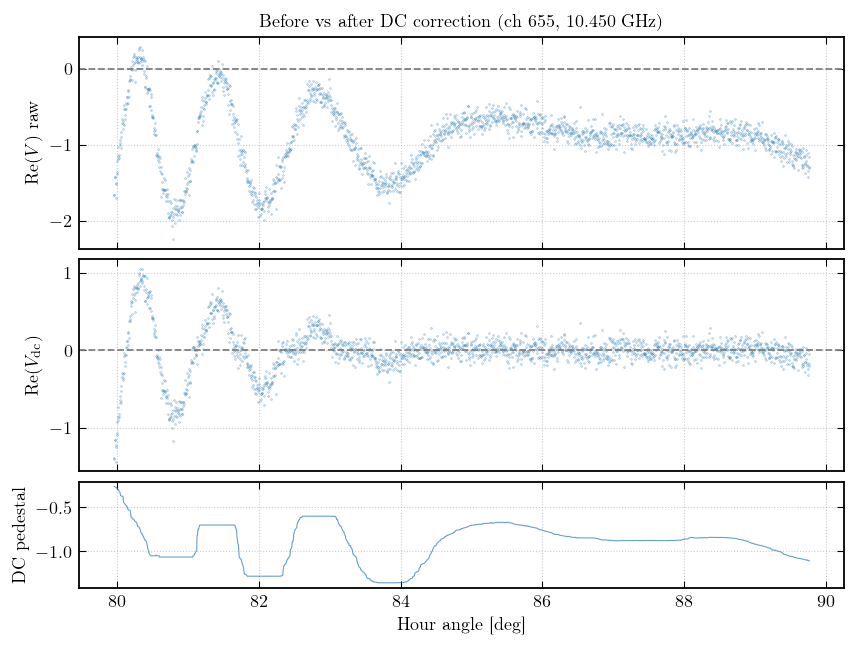

In [8]:
# ── Before / after comparison (representative channel) ─────────────
vis_dc_ch = corr_dc[:, k_mid]

fig, axes = plt.subplots(3, 1, figsize=(TEXTWIDTH_IN, 5.5), sharex=True,
                         gridspec_kw={"hspace": 0.06, "height_ratios": [2, 2, 1]})

# (a) Raw Re(V)
axes[0].scatter(ha_deg_arr, corr_raw[:, k_mid].real, s=0.15, color="C0",
                alpha=0.4, rasterized=True)
axes[0].axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")
axes[0].set_ylabel(r"Re$(V)$ raw")
axes[0].set_title(f"Before vs after DC correction (ch {k_mid}, {f_mid_ghz:.3f} GHz)",
                  fontsize=TICK_SIZE)

# (b) Corrected Re(V)
axes[1].scatter(ha_deg_arr, vis_dc_ch.real, s=0.15, color="C0",
                alpha=0.4, rasterized=True)
axes[1].axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")
axes[1].set_ylabel(r"Re$(V_{\rm dc})$")

# (c) Subtracted pedestal
axes[2].plot(ha_deg_arr, real_offset[:, k_mid], lw=LW_FINE, color="C0", alpha=0.7)
axes[2].set_ylabel("DC pedestal")
axes[2].set_xlabel("Hour angle [deg]")

fig.tight_layout()
plt.show()

## 5. Observation timeline and cadence

/tmp/ipykernel_213819/663388767.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


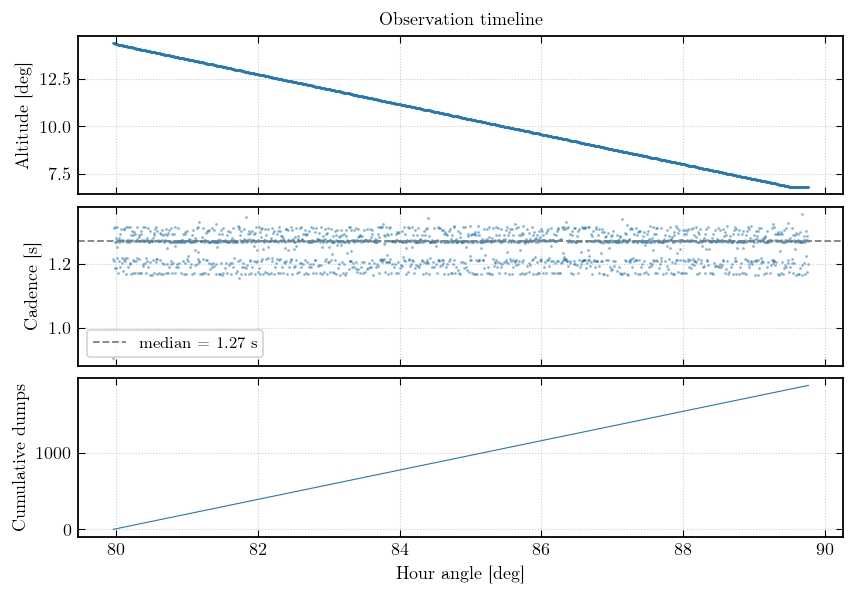

Total dumps:     1885
Median cadence:  1.269 s
HA range:        80.0 to 89.8 deg
Alt range:       6.8 to 14.4 deg


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(TEXTWIDTH_IN, 5.0), sharex=True,
                         gridspec_kw={"hspace": 0.08})

# (a) Altitude
axes[0].scatter(ha_deg_arr, alt_deg_arr, s=0.3, color="C0",
                alpha=0.5, rasterized=True)
axes[0].set_ylabel("Altitude [deg]")
axes[0].set_title("Observation timeline", fontsize=TICK_SIZE)

# (b) Inter-dump cadence
axes[1].scatter(ha_deg_arr[:-1], dt, s=0.3, color="C0",
                alpha=0.5, rasterized=True)
axes[1].set_ylabel("Cadence [s]")
axes[1].axhline(median_cadence, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--",
                label=f"median = {median_cadence:.2f} s")
axes[1].legend(fontsize=TICK_SIZE - 1)

# (c) Cumulative dumps
axes[2].plot(ha_deg_arr, np.arange(N_dumps), lw=LW_FINE, color="C0")
axes[2].set_ylabel("Cumulative dumps")
axes[2].set_xlabel("Hour angle [deg]")

fig.tight_layout()
plt.show()

print(f"Total dumps:     {N_dumps}")
print(f"Median cadence:  {median_cadence:.3f} s")
print(f"HA range:        {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")
print(f"Alt range:       {alt_deg_arr.min():.1f} to {alt_deg_arr.max():.1f} deg")

## 5b. Duty cycle

The **duty cycle** is the fraction of wall-clock time spent integrating.
Each SNAP dump accumulates for `acc_cnt` clock cycles at the correlator
clock rate; the rest is overhead (readout, repointing, disk I/O). A low
duty cycle means the observation is overhead-dominated and the effective
sensitivity is reduced.

/tmp/ipykernel_213819/2394310814.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


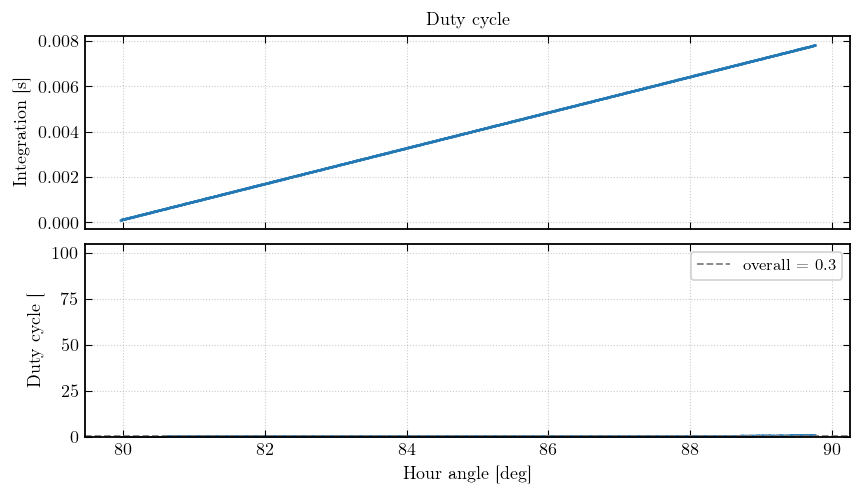

Median integration per dump: 0.004 s
Total integration time:      7.5 s
Total wall-clock time:       2354.8 s
Overall duty cycle:          0.3%


In [10]:
# ── Duty cycle ──────────────────────────────────────────────────────
# Integration time per dump: acc_cnt * (N_FFT / F_S_HZ) seconds
# (each accumulation is one FFT window of N_FFT samples at F_S_HZ)
t_int_per_dump = acc_cnt_arr * (N_FFT / F_S_HZ)  # seconds

# Wall-clock cadence between consecutive dumps
wall_cadence = np.diff(unix_arr)

# Per-gap duty cycle: fraction of wall time spent integrating
duty_per_gap = t_int_per_dump[:-1] / wall_cadence

# Overall duty cycle
total_int_time = float(np.sum(t_int_per_dump))
total_wall_time = float(unix_arr[-1] - unix_arr[0])
overall_duty = total_int_time / total_wall_time

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.0), sharex=True,
                         gridspec_kw={"hspace": 0.08})

# (a) Integration time per dump
axes[0].scatter(ha_deg_arr, t_int_per_dump, s=0.3, color="C0",
                alpha=0.5, rasterized=True)
axes[0].set_ylabel("Integration [s]")
axes[0].set_title("Duty cycle", fontsize=TICK_SIZE)

# (b) Duty cycle per gap
axes[1].scatter(ha_deg_arr[:-1], duty_per_gap * 100, s=0.3, color="C0",
                alpha=0.5, rasterized=True)
axes[1].axhline(overall_duty * 100, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--",
                label=f"overall = {overall_duty * 100:.1f}%")
axes[1].set_ylabel("Duty cycle [%]")
axes[1].set_xlabel("Hour angle [deg]")
axes[1].set_ylim(0, 105)
axes[1].legend(fontsize=TICK_SIZE - 1)

fig.tight_layout()
plt.show()

print(f"Median integration per dump: {np.median(t_int_per_dump):.3f} s")
print(f"Total integration time:      {total_int_time:.1f} s")
print(f"Total wall-clock time:       {total_wall_time:.1f} s")
print(f"Overall duty cycle:          {overall_duty * 100:.1f}%")

## 6. Summary statistics

In [11]:
import datetime as _dt

t0 = _dt.datetime.fromtimestamp(unix_arr[0], tz=_dt.UTC)
t1 = _dt.datetime.fromtimestamp(unix_arr[-1], tz=_dt.UTC)

# Per-dump noise: across-channel scatter in the analysis band
sigma_per_dump = np.nanstd(np.abs(corr_band), axis=1) / np.sqrt(band_mask.sum())
sigma_median = float(np.nanmedian(sigma_per_dump))

# Band-averaged amplitude
band_amp = np.nanmedian(np.abs(corr_band), axis=1)

# Duty cycle: fraction of wall-clock time spent integrating.
# Each dump integrates for one acc_len cycle; the rest is dead time
# (readout, queue latency, disk I/O).  The accumulation time per dump
# is approximated as the minimum inter-dump interval (the floor set by
# the FPGA accumulator), and the wall-clock span is the total elapsed time.
wall_clock_sec = unix_arr[-1] - unix_arr[0]
min_cadence = float(np.min(dt))
integration_sec = N_dumps * min_cadence
duty_cycle = integration_sec / wall_clock_sec

print(f"Observation start (UTC): {t0:%Y-%m-%d %H:%M:%S}")
print(f"Observation end   (UTC): {t1:%Y-%m-%d %H:%M:%S}")
print(f"Duration:                {wall_clock_sec / 60:.1f} min")
print(f"Dumps:                   {N_dumps}")
print(f"Channels:                {N_CH} ({F_SKY_GHZ[0]:.3f}–{F_SKY_GHZ[-1]:.3f} GHz)")
print(f"Analysis band:           {PLOT_BAND_GHZ[0]:.3f}–{PLOT_BAND_GHZ[1]:.3f} GHz "
      f"({band_mask.sum()} good channels)")
print(f"Bad channels:            {list(BAD_CHANNELS)}")
print(f"Median cadence:          {median_cadence:.3f} s")
print(f"Min cadence (≈ t_acc):   {min_cadence:.3f} s")
print(f"Duty cycle:              {duty_cycle:.1%} "
      f"({integration_sec:.0f} / {wall_clock_sec:.0f} s)")
print(f"HA range:                {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")
print(f"Sun RA range:            {ra_deg_arr.min():.3f} to {ra_deg_arr.max():.3f} deg")
print(f"Sun Dec range:           {dec_deg_arr.min():.3f} to {dec_deg_arr.max():.3f} deg")
print(f"Alt range:               {alt_deg_arr.min():.1f} to {alt_deg_arr.max():.1f} deg")
print(f"Median |V| (band avg):   {np.nanmedian(band_amp):.4f}")
print(f"Per-dump sigma_V:        {sigma_median:.4g}")

Observation start (UTC): 2026-04-16 01:27:20
Observation end   (UTC): 2026-04-16 02:06:34
Duration:                39.2 min
Dumps:                   1885
Channels:                1024 (10.290–10.540 GHz)
Analysis band:           10.415–10.485 GHz (285 good channels)
Bad channels:            [0, 256, 512, 768]
Median cadence:          1.269 s
Min cadence (≈ t_acc):   0.906 s
Duty cycle:              72.5% (1707 / 2355 s)
HA range:                80.0 to 89.8 deg
Sun RA range:            23.835 to 23.859 deg
Sun Dec range:           9.935 to 9.945 deg
Alt range:               6.8 to 14.4 deg
Median |V| (band avg):   0.9403
Per-dump sigma_V:        0.01625


## 7. Flux calibration: correlator units to Janskys

### The normalized correlation coefficient

The auto-correlation calibration scan provides the per-antenna total power
$P_0(\nu)$ and $P_1(\nu)$ in correlator units. Dividing the cross-correlation
by the geometric mean of the auto-correlations removes the arbitrary gain
scaling and yields the **normalized correlation coefficient**:

$$\hat{r}_{12}(\nu) = \frac{V_{12}(\nu)}{\sqrt{P_0(\nu) \cdot P_1(\nu)}},$$

which is dimensionless and ranges from 0 (no correlated signal) to 1
(fully correlated, point source at phase centre).

### From $\hat{r}_{12}$ to Janskys via the SEFD

The correlation coefficient relates to flux density through the **System
Equivalent Flux Density** (SEFD), which absorbs the dish area, system
temperature, and correlator gain into a single number:

$$S_{\mathrm{corr}}(\nu) = \mathrm{SEFD}_{12} \times \hat{r}_{12}(\nu) \qquad [\mathrm{Jy}].$$

### Bootstrapping the SEFD from the Sun

The NCH antenna parameters (dish diameter, aperture efficiency, $T_{\rm sys}$)
are not documented in the codebase, so we calibrate empirically using the
Sun as a source of assumed flux. At 10.5 GHz the quiet-to-moderate Sun has
a total flux density $S_\odot \approx 150\;\mathrm{SFU} = 1.5 \times 10^6\;\mathrm{Jy}$
(a working estimate; the actual value for this date can be refined from the
Penticton F10.7 daily index scaled to 10.5 GHz).

The Sun is resolved, so the correlated flux is modulated by the disk visibility:

$$S_{\mathrm{corr}} = S_\odot \times |V_{\mathrm{disk}}(q)|, \qquad
|V_{\mathrm{disk}}| = \left|\frac{2\,J_1(2\pi q R)}{2\pi q R}\right|,$$

where $q$ is the projected baseline in wavelengths and $R \approx 16.3'$
is the radio solar radius. Solving for the SEFD:

$$\mathrm{SEFD}_{12} = \frac{S_\odot \times |V_{\mathrm{disk}}(q)|}{\hat{r}_{12}}.$$

Take the median across dumps and analysis-band channels to obtain one
calibration constant. This SEFD then converts any future $\hat{r}_{12}$
measurement (Sun or otherwise) into Jy.

/tmp/ipykernel_213819/1280846438.py:27: RuntimeWarning: divide by zero encountered in divide
  sefd_per_dump = S_SUN_JY * v_disk / r_hat_amp  # (N_dumps, N_CH)


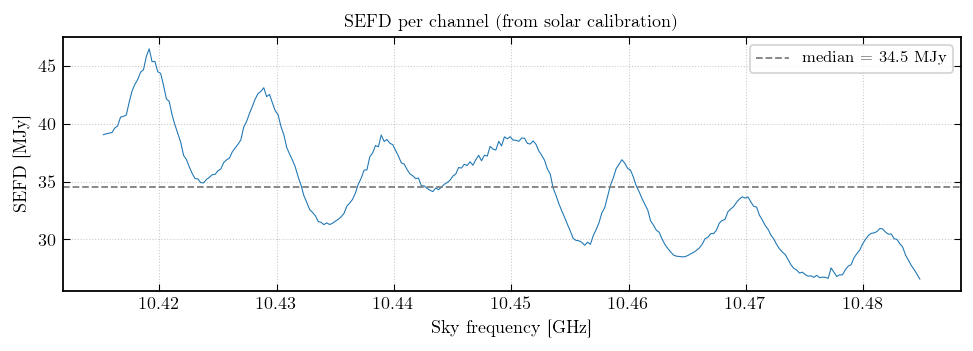

Assumed S_sun = 2e+06 Jy (150 SFU)
Median SEFD (analysis band): 3.452e+07 Jy = 34.5 MJy


In [12]:
from scipy.special import j1 as J1

# ── Normalized correlation coefficient ─────────────────────────────
# Use uncorrected cross- and auto-correlations so the ratio cancels
# common gain and DC biases.
geo_mean_auto = np.sqrt(auto0_mean[None, :] * auto1_mean[None, :])  # (1, N_CH)
r_hat = corr_raw / geo_mean_auto  # (N_dumps, N_CH) complex

# ── Solar disk visibility at each dump ─────────────────────────────
from utils import NOMINAL_B_NS_M, sky_baseline_lambda

S_SUN_JY = 1.5e6  # assumed 150 SFU at 10.5 GHz
R_SUN_RAD = np.deg2rad(16.3 / 60.0)  # radio solar radius

q_per_ch = np.empty((N_dumps, N_CH), dtype=float)
for k in range(N_CH):
    q_per_ch[:, k] = sky_baseline_lambda(
        ha_rad_arr, dec_rad_mean, NOMINAL_B_EW_M, NOMINAL_B_NS_M, float(F_SKY_HZ[k])
    )

x_bessel = 2 * np.pi * q_per_ch * R_SUN_RAD
v_disk = np.where(x_bessel > 1e-8, np.abs(2 * J1(x_bessel) / x_bessel), 1.0)

# ── SEFD per frequency channel ─────────────────────────────────────
# SEFD = S_sun * |V_disk| / |r_hat|, take median across dumps
r_hat_amp = np.abs(r_hat)
sefd_per_dump = S_SUN_JY * v_disk / r_hat_amp  # (N_dumps, N_CH)
sefd_per_ch = np.nanmedian(sefd_per_dump[:, band_mask], axis=0)  # (N_band,)

band_freqs = F_SKY_GHZ[band_mask]
sefd_median = float(np.nanmedian(sefd_per_ch))

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.8))
ax.plot(band_freqs, sefd_per_ch / 1e6, lw=LW_FINE, color="C0")
ax.axhline(sefd_median / 1e6, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--",
           label=f"median = {sefd_median / 1e6:.1f} MJy")
ax.set_xlabel("Sky frequency [GHz]")
ax.set_ylabel("SEFD [MJy]")
ax.set_title("SEFD per channel (from solar calibration)", fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE - 1)
fig.tight_layout()
plt.show()

print(f"Assumed S_sun = {S_SUN_JY:.0e} Jy (150 SFU)")
print(f"Median SEFD (analysis band): {sefd_median:.3e} Jy = {sefd_median / 1e6:.1f} MJy")

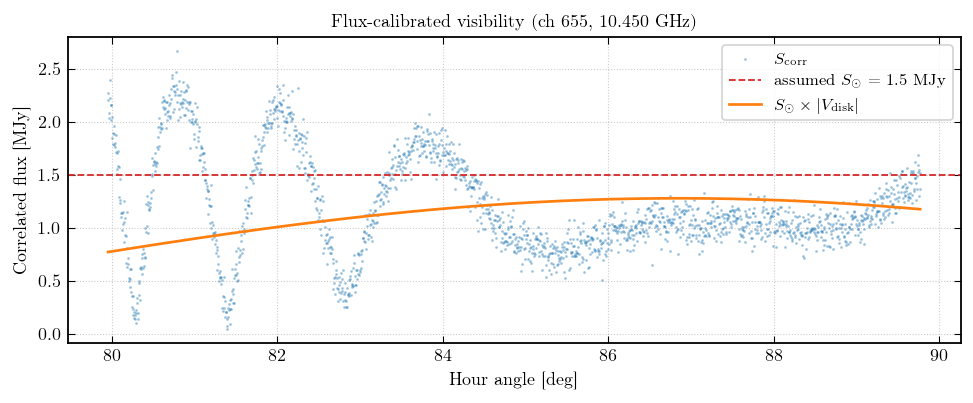

In [13]:
# ── Flux-calibrated visibility at representative channel ───────────
S_corr_ch = sefd_median * np.abs(r_hat[:, k_mid])  # Jy

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 3.2))
ax.scatter(ha_deg_arr, S_corr_ch / 1e6, s=0.3, color="C0",
           alpha=0.4, rasterized=True, label="$S_{\\rm corr}$")
ax.axhline(S_SUN_JY / 1e6, color="C3", lw=LW_LIGHT, ls="--",
           label=f"assumed $S_\\odot$ = {S_SUN_JY / 1e6:.1f} MJy")

# Expected correlated flux: S_sun * |V_disk(q)|
S_expected = S_SUN_JY * v_disk[:, k_mid]
ha_sort = np.argsort(ha_deg_arr)
ax.plot(ha_deg_arr[ha_sort], S_expected[ha_sort] / 1e6,
        color="C1", lw=LW_STANDARD, label="$S_\\odot \\times |V_{\\rm disk}|$")

ax.set_xlabel("Hour angle [deg]")
ax.set_ylabel("Correlated flux [MJy]")
ax.set_title(f"Flux-calibrated visibility (ch {k_mid}, {f_mid_ghz:.3f} GHz)",
             fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE - 1)
fig.tight_layout()
plt.show()